
# PyTorch FNN Regression

이 노트북은 Google Drive의 `test.csv`를 불러와 다음 작업을 수행합니다.

- 입력: `data1`
- 출력: `data2`
- Train/Test 데이터는 동일하게 사용
- 표준화
- PyTorch 기반 FNN 회귀모델 학습
- Epoch별 Train/Test loss 저장
- 실제값/추정값 비교 그림 저장
- 추정 결과 CSV 저장
- 학습 모델 및 scaler 저장


In [ ]:

# 1. 라이브러리 및 Google Drive 연결

import os
import random
import copy
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import drive

# GitHub repository를 저장할 위치
REPO_ROOT = "/content/Basic_example_copy"
# 저장소가 없으면 clone
if not os.path.exists(REPO_ROOT):
    !git clone -q https://github.com/Jaehoon-Shim/Basic_example.git {REPO_ROOT}
os.makedirs('/content/Basic_example_copy/data', exist_ok=True)
os.makedirs('/content/Basic_example_copy/results', exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# 2. 설정

SEED = 42
EPOCHS = 400
LEARNING_RATE = 2e-3
PRINT_INTERVAL = 1

BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/Basic_example_copy'
RESULT_DIR = os.path.join(BASE_DIR, 'pytorch_results')
CSV_PATH = os.path.join(BASE_DIR, 'data/test.csv')

os.makedirs(RESULT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device    :', DEVICE)
print('CSV Path  :', CSV_PATH)
print('Result Dir:', RESULT_DIR)
print('CSV Exists:', os.path.exists(CSV_PATH))


Device    : cpu
CSV Path  : /content/drive/MyDrive/Colab Notebooks/Basic_example/data/test.csv
Result Dir: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results
CSV Exists: True


In [70]:

# 3. CSV 로드 및 전처리

df = pd.read_csv(CSV_PATH)

# 불필요한 인덱스 열 제거
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]

required_columns = ['data1', 'data2']

if not all(col in df.columns for col in required_columns):
    raise ValueError(
        f'CSV에 {required_columns} 열이 필요합니다. '
        f'현재 열: {df.columns.tolist()}'
    )

df = df[required_columns].copy()

df['data1'] = pd.to_numeric(df['data1'], errors='coerce')
df['data2'] = pd.to_numeric(df['data2'], errors='coerce')

df = df.dropna().reset_index(drop=True)

print('Data shape:', df.shape)
display(df.head())
display(df.describe())


Data shape: (360, 2)


,data1,data2
0,0.0,0.851328
1,0.1,0.529329
2,0.2,0.492070
3,0.3,0.512491
4,0.4,1.046291


,data1,data2
count,360.000000,360.000000
mean,17.950000,3.547375
std,10.406729,3.800462
min,0.000000,0.087839
25%,8.975000,0.740147
50%,17.950000,1.641251
75%,26.925000,5.487954
max,35.900000,14.246263


In [71]:

# 4. 입력/출력 구성 및 표준화

X = df[['data1']].to_numpy(dtype=np.float32)
y = df[['data2']].to_numpy(dtype=np.float32)

# 요청에 따라 train/test 동일
X_train = X.copy()
y_train = y.copy()

X_test = X.copy()
y_test = y.copy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train).astype(np.float32)
y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

X_test_scaled = x_scaler.transform(X_test).astype(np.float32)
y_test_scaled = y_scaler.transform(y_test).astype(np.float32)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32, device=DEVICE)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32, device=DEVICE)

print('X_train:', X_train_tensor.shape)
print('y_train:', y_train_tensor.shape)


X_train: torch.Size([360, 1])
y_train: torch.Size([360, 1])


In [72]:

# 5. FNN 모델 정의

class FNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.model(x)


model = FNNRegressor().to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=100
)

print(model)


FNNRegressor(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [73]:
# 6. 모델 학습 + Epoch별 Weight/Bias 저장

train_loss_history = []
test_loss_history = []

best_test_loss = float('inf')
best_model_state = None

# ------------------------------------------------------------
# Epoch별 파라미터 변화 저장
# model.named_parameters() 예:
# model.0.weight, model.0.bias,
# model.2.weight, model.2.bias, ...
# ------------------------------------------------------------
parameter_history = {
    name: []
    for name, param in model.named_parameters()
}

# 학습 시작 전 초기값도 별도 저장
initial_parameters = {
    name: param.detach().cpu().numpy().copy()
    for name, param in model.named_parameters()
}

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()

    optimizer.zero_grad()

    train_pred = model(X_train_tensor)
    train_loss = criterion(train_pred, y_train_tensor)

    train_loss.backward()
    optimizer.step()

    # --------------------------------------------------------
    # optimizer.step() 이후의 Weight/Bias를 저장
    # --------------------------------------------------------
    for name, param in model.named_parameters():
        parameter_history[name].append(
            param.detach().cpu().numpy().copy()
        )

    # Test
    model.eval()

    with torch.no_grad():
        test_pred = model(X_test_tensor)
        test_loss = criterion(test_pred, y_test_tensor)

    train_loss_value = train_loss.item()
    test_loss_value = test_loss.item()

    train_loss_history.append(train_loss_value)
    test_loss_history.append(test_loss_value)

    scheduler.step(test_loss_value)

    if test_loss_value < best_test_loss:
        best_test_loss = test_loss_value
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % PRINT_INTERVAL == 0:
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f'Epoch {epoch:4d}/{EPOCHS} | '
            f'Train Loss: {train_loss_value:.8f} | '
            f'Test Loss: {test_loss_value:.8f} | '
            f'LR: {current_lr:.6f}'
        )

# parameter_history는 실제 학습 과정의 trajectory를 그대로 유지
# 아래에서는 최종 평가를 위해 best model을 다시 로드
model.load_state_dict(best_model_state)

print()
print('Best Test Loss:', best_test_loss)


Epoch    1/400 | Train Loss: 0.96622825 | Test Loss: 0.95833462 | LR: 0.002000
Epoch    2/400 | Train Loss: 0.95833462 | Test Loss: 0.95036232 | LR: 0.002000
Epoch    3/400 | Train Loss: 0.95036232 | Test Loss: 0.94231540 | LR: 0.002000
Epoch    4/400 | Train Loss: 0.94231540 | Test Loss: 0.93420386 | LR: 0.002000
Epoch    5/400 | Train Loss: 0.93420386 | Test Loss: 0.92603862 | LR: 0.002000
Epoch    6/400 | Train Loss: 0.92603862 | Test Loss: 0.91798156 | LR: 0.002000
Epoch    7/400 | Train Loss: 0.91798156 | Test Loss: 0.91025645 | LR: 0.002000
Epoch    8/400 | Train Loss: 0.91025645 | Test Loss: 0.90305585 | LR: 0.002000
Epoch    9/400 | Train Loss: 0.90305585 | Test Loss: 0.89621580 | LR: 0.002000
Epoch   10/400 | Train Loss: 0.89621580 | Test Loss: 0.88913625 | LR: 0.002000
Epoch   11/400 | Train Loss: 0.88913625 | Test Loss: 0.88175458 | LR: 0.002000
Epoch   12/400 | Train Loss: 0.88175458 | Test Loss: 0.87411416 | LR: 0.002000
Epoch   13/400 | Train Loss: 0.87411416 | Test Loss:

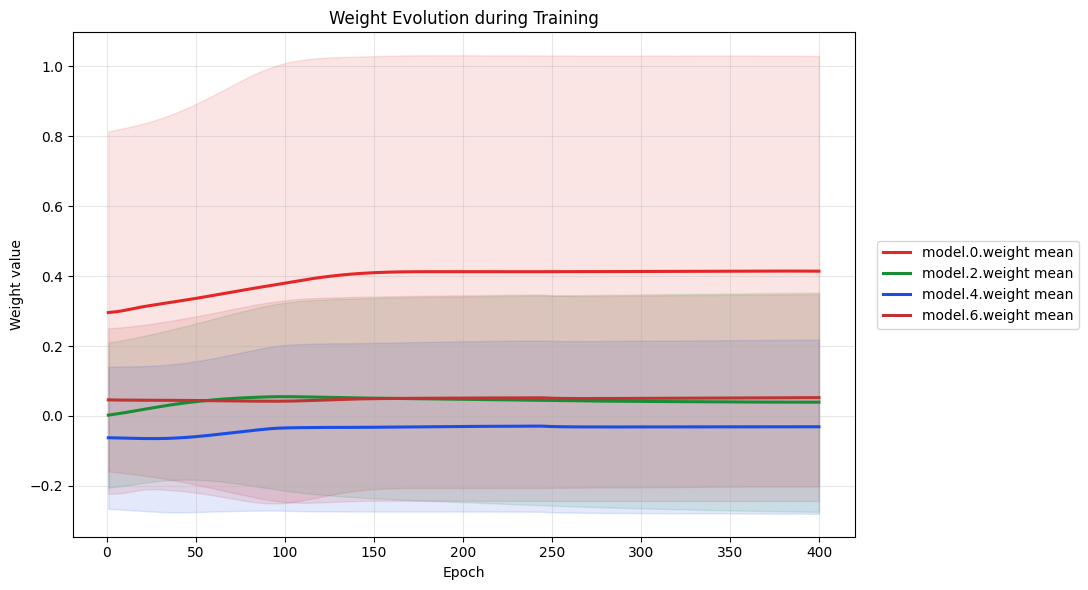

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/weight_evolution_summary.jpg


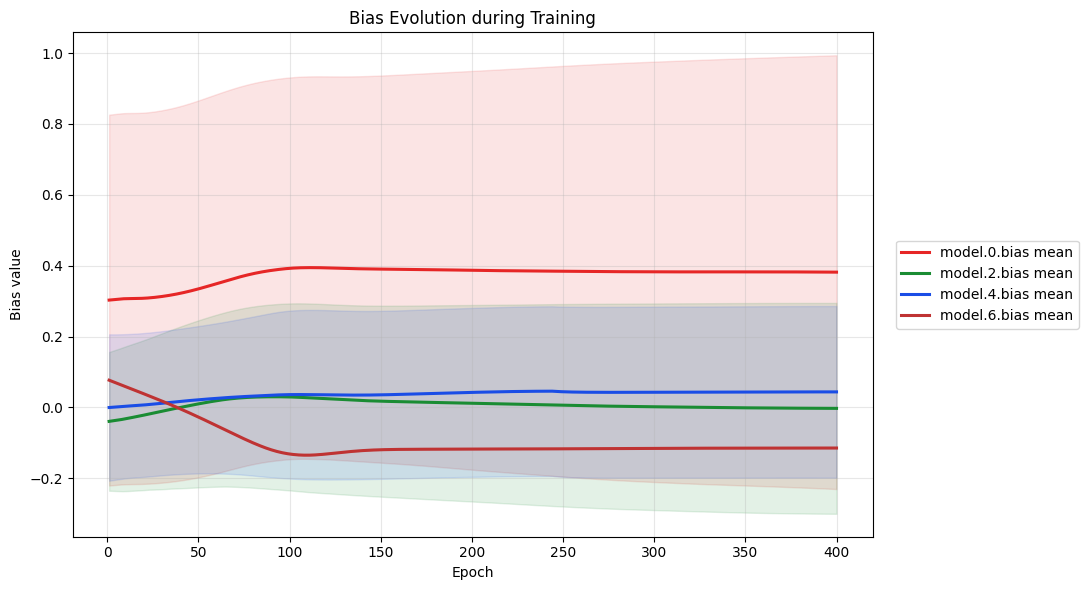

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/bias_evolution_summary.jpg


In [60]:
# 6-1. Epoch별 Weight/Bias 변화 - 평균 ± 표준편차 요약 플롯

epochs_param = np.arange(1, EPOCHS + 1)

# RGB 계열 색상
RGB_COLORS = [
    (0.90, 0.15, 0.15),  # Red
    (0.10, 0.55, 0.20),  # Green
    (0.10, 0.30, 0.90),  # Blue
    (0.75, 0.20, 0.20),  # Dark red
    (0.10, 0.40, 0.15),  # Dark green
    (0.10, 0.20, 0.65),  # Dark blue
    (1.00, 0.40, 0.40),  # Light red
    (0.35, 0.75, 0.35),  # Light green
]

weight_names = [name for name in parameter_history if name.endswith('weight')]
bias_names   = [name for name in parameter_history if name.endswith('bias')]

# -------------------------
# Weight summary
# -------------------------
plt.figure(figsize=(11, 6))

for idx, name in enumerate(weight_names):
    history = np.asarray(parameter_history[name])   # [epoch, ...]
    flat = history.reshape(EPOCHS, -1)

    mean_value = flat.mean(axis=1)
    std_value = flat.std(axis=1)

    color = RGB_COLORS[idx % len(RGB_COLORS)]

    plt.plot(
        epochs_param,
        mean_value,
        color=color,
        linewidth=2.2,
        label=f'{name} mean'
    )

    plt.fill_between(
        epochs_param,
        mean_value - std_value,
        mean_value + std_value,
        color=color,
        alpha=0.12
    )

plt.xlabel('Epoch')
plt.ylabel('Weight value')
plt.title('Weight Evolution during Training')
plt.grid(True, alpha=0.3)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout()

weight_summary_path = os.path.join(
    RESULT_DIR,
    'weight_evolution_summary.jpg'
)

plt.savefig(
    weight_summary_path,
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print('Saved:', weight_summary_path)


# -------------------------
# Bias summary
# -------------------------
plt.figure(figsize=(11, 6))

for idx, name in enumerate(bias_names):
    history = np.asarray(parameter_history[name])
    flat = history.reshape(EPOCHS, -1)

    mean_value = flat.mean(axis=1)
    std_value = flat.std(axis=1)

    color = RGB_COLORS[idx % len(RGB_COLORS)]

    plt.plot(
        epochs_param,
        mean_value,
        color=color,
        linewidth=2.2,
        label=f'{name} mean'
    )

    plt.fill_between(
        epochs_param,
        mean_value - std_value,
        mean_value + std_value,
        color=color,
        alpha=0.12
    )

plt.xlabel('Epoch')
plt.ylabel('Bias value')
plt.title('Bias Evolution during Training')
plt.grid(True, alpha=0.3)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout()

bias_summary_path = os.path.join(
    RESULT_DIR,
    'bias_evolution_summary.jpg'
)

plt.savefig(
    bias_summary_path,
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print('Saved:', bias_summary_path)


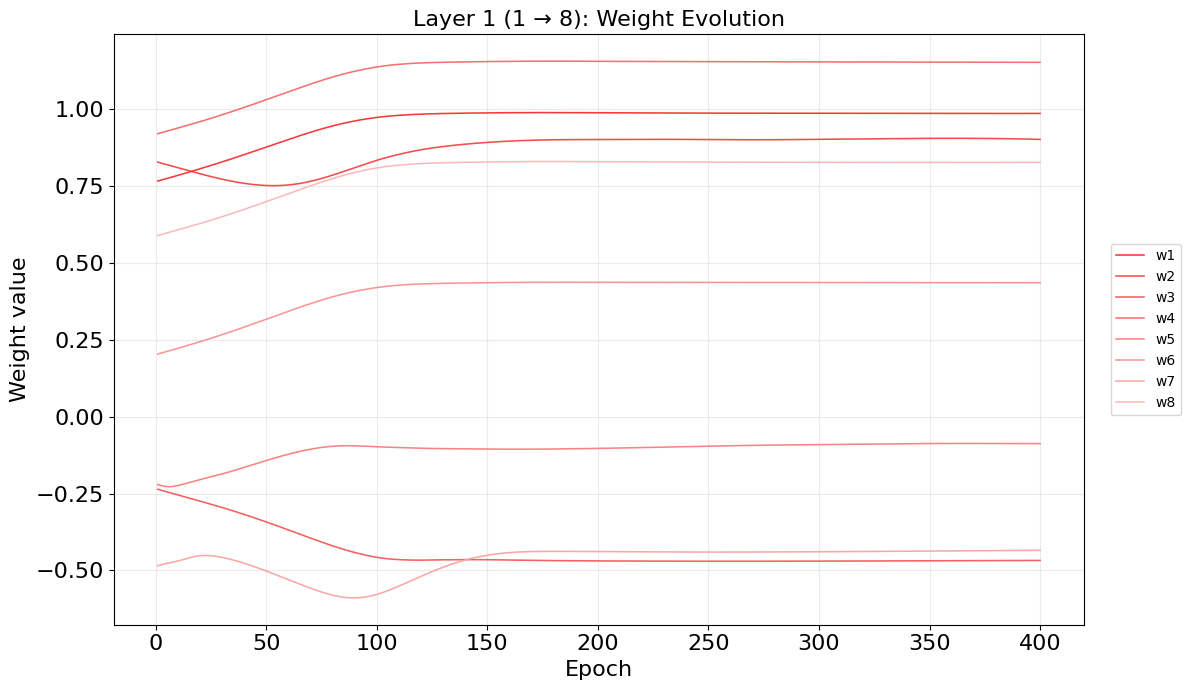

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/model_0_weight_evolution.jpg


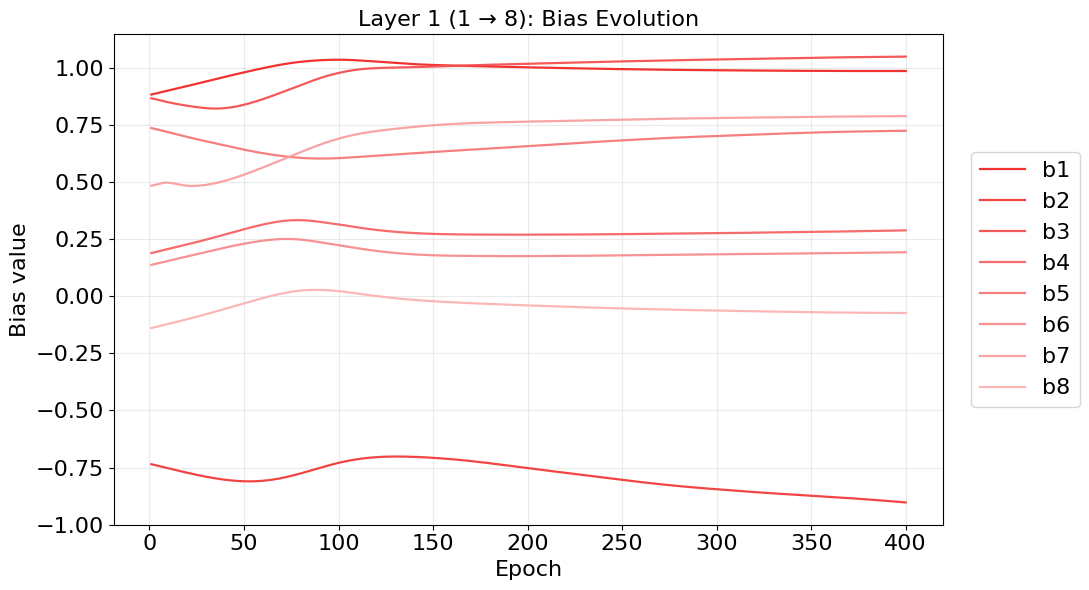

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/model_0_bias_evolution.jpg


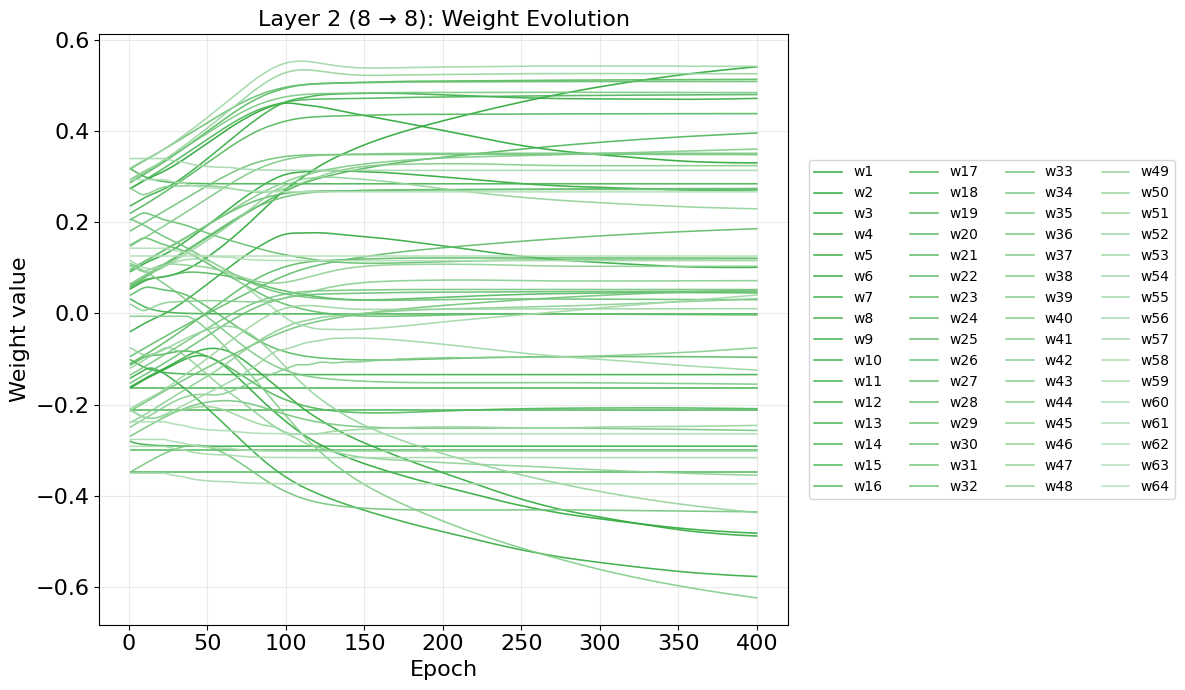

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/model_2_weight_evolution.jpg


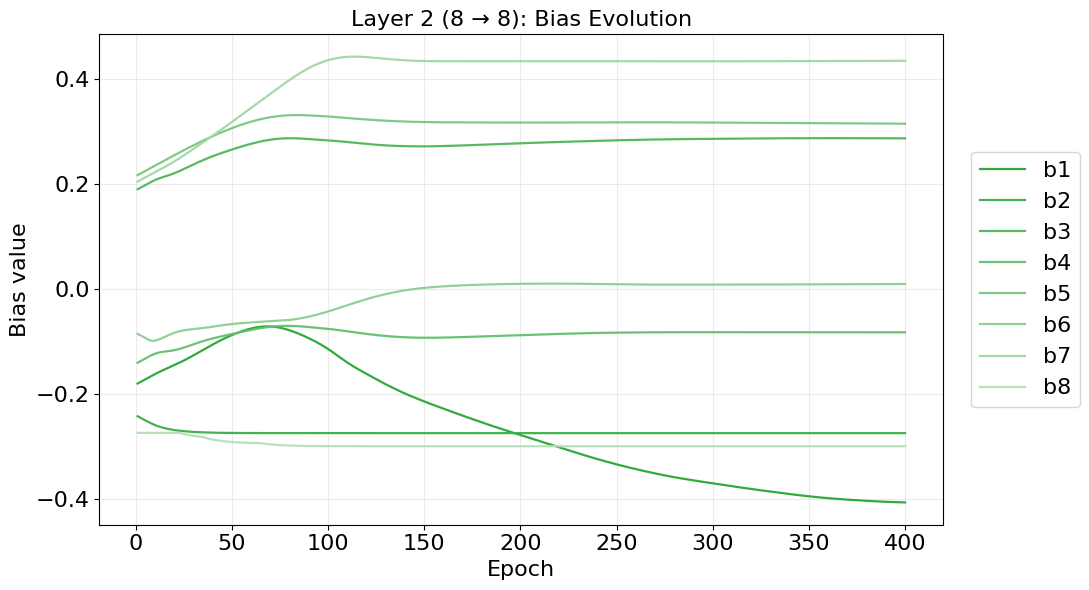

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/model_2_bias_evolution.jpg


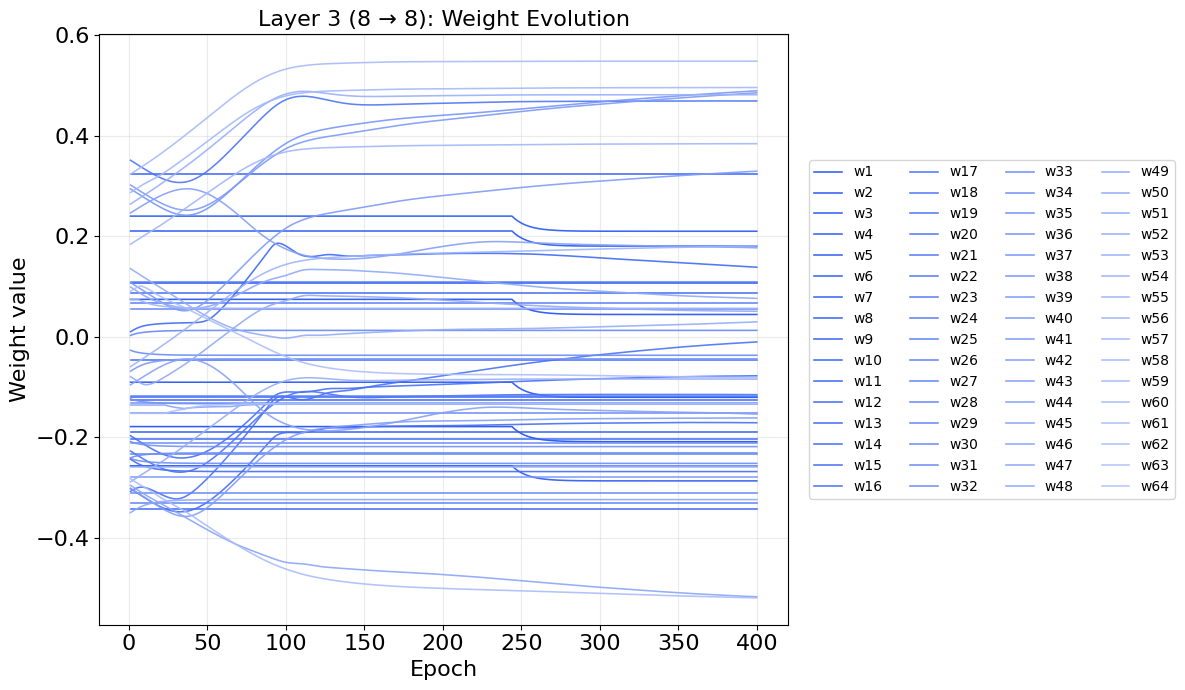

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/model_4_weight_evolution.jpg


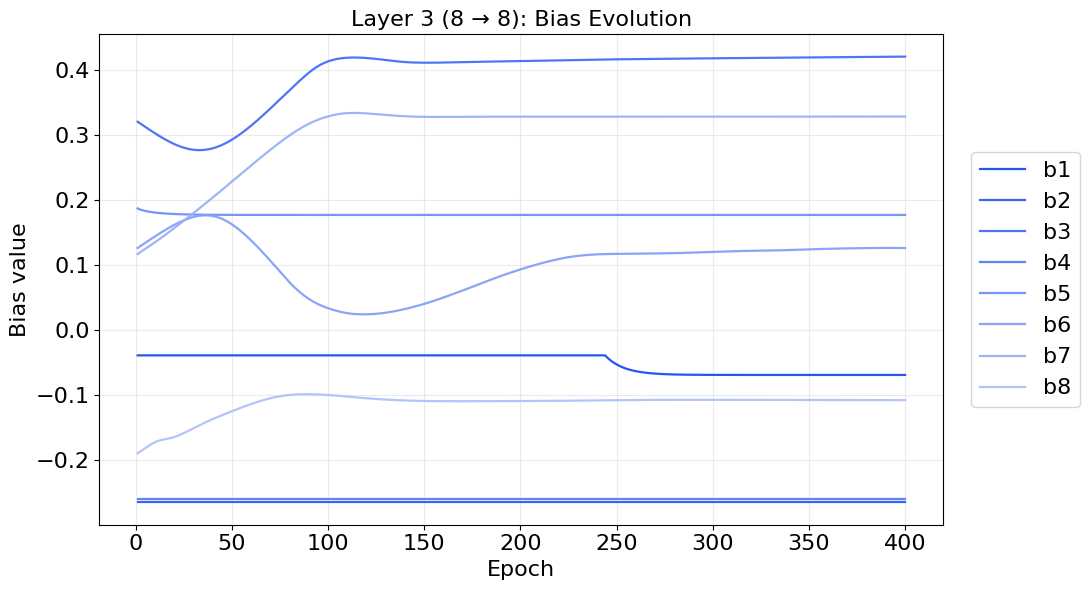

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/model_4_bias_evolution.jpg


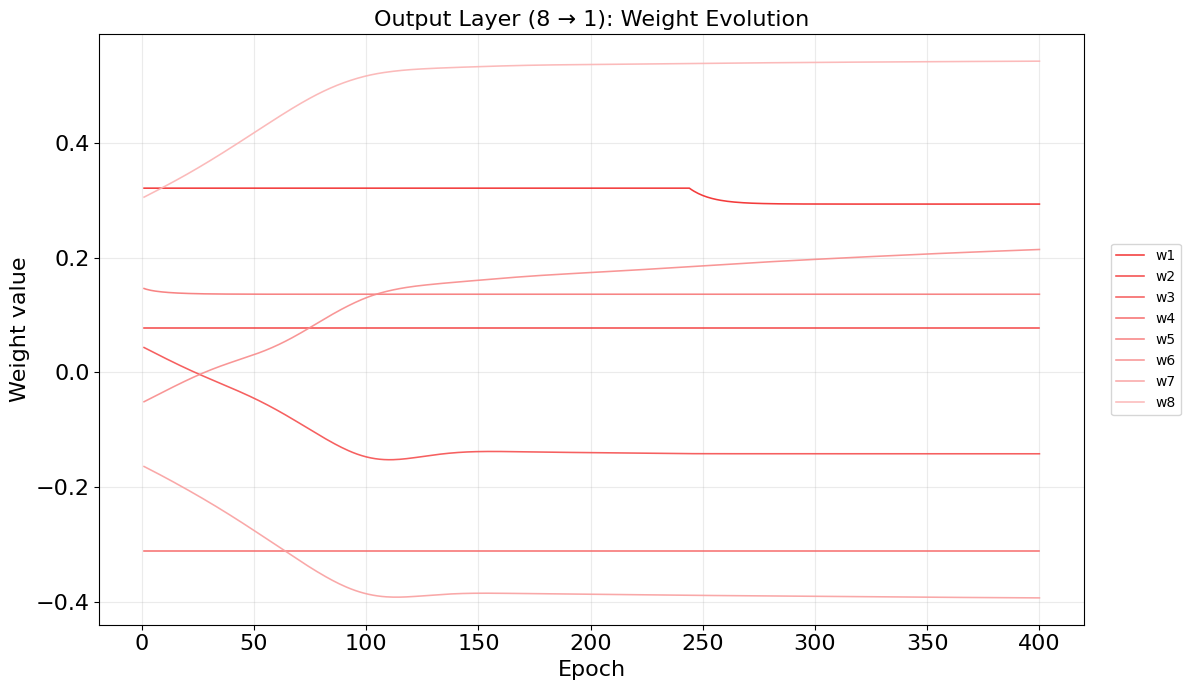

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/model_6_weight_evolution.jpg


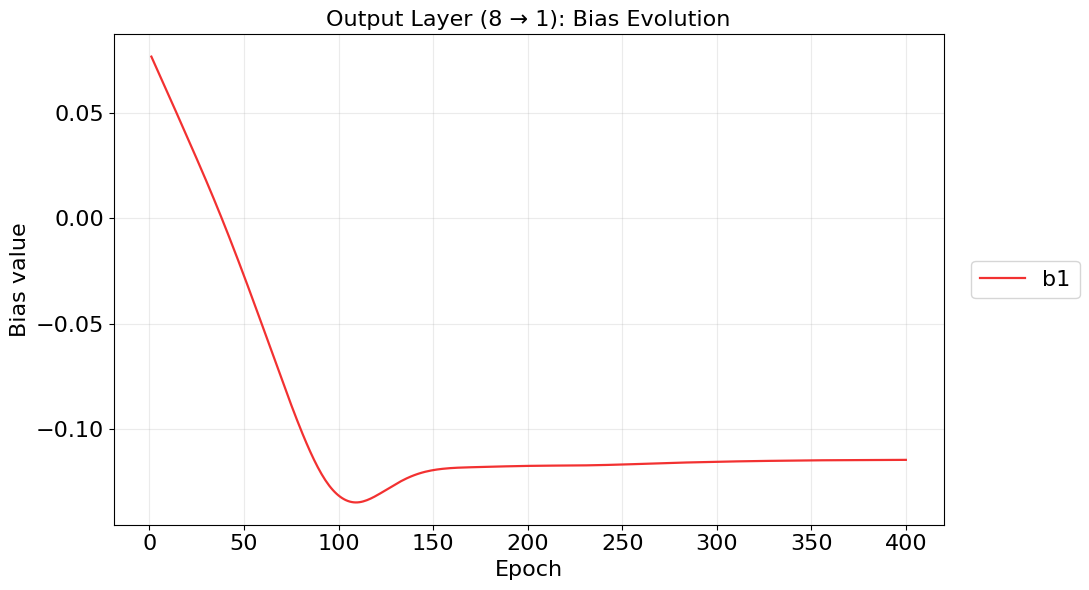

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/model_6_bias_evolution.jpg


In [76]:
# 6-2. 각 Layer의 개별 Weight/Bias 변화 플롯
# 모든 파라미터를 개별 선으로 확인하고 싶은 경우 사용
# Dense layer(8x8)는 64개 weight이므로 legend는 그래프 밖에 배치

RGB_FAMILY = [
    (0.95, 0.15, 0.15),  # R
    (0.15, 0.65, 0.20),  # G
    (0.10, 0.30, 0.95),  # B
]

def make_rgb_shades(base_rgb, n):
    """
    지정 RGB 계열에서 흰색 쪽으로 단계적으로 섞어
    같은 계열의 여러 색상을 생성
    """
    base = np.array(base_rgb, dtype=float)
    white = np.ones(3)

    if n == 1:
        return [tuple(base)]

    ratios = np.linspace(0.0, 0.65, n)
    return [
        tuple(base * (1-r) + white * r)
        for r in ratios
    ]


layer_pairs = [
    ('model.0.weight', 'model.0.bias', 'Layer 1 (1 → 8)', RGB_FAMILY[0]),
    ('model.2.weight', 'model.2.bias', 'Layer 2 (8 → 8)', RGB_FAMILY[1]),
    ('model.4.weight', 'model.4.bias', 'Layer 3 (8 → 8)', RGB_FAMILY[2]),
    ('model.6.weight', 'model.6.bias', 'Output Layer (8 → 1)', RGB_FAMILY[0]),
]

for weight_name, bias_name, layer_title, base_color in layer_pairs:

    # ========================================================
    # Weight
    # ========================================================
    weight_hist = np.asarray(parameter_history[weight_name])
    weight_flat = weight_hist.reshape(EPOCHS, -1)

    colors = make_rgb_shades(base_color, weight_flat.shape[1])

    plt.figure(figsize=(12, 7))

    for j in range(weight_flat.shape[1]):
        plt.plot(
            epochs_param,
            weight_flat[:, j],
            color=colors[j],
            linewidth=1.15,
            alpha=0.9,
            label=f'w{j+1}'
        )

    plt.xlabel('Epoch', fontsize=16)
    plt.ylabel('Weight value', fontsize=16)
    plt.title(f'{layer_title}: Weight Evolution', fontsize=16)
    plt.grid(True, alpha=0.25)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(fontsize=8)

    # 64개 legend는 여러 column로 분할
    ncol = 1 if weight_flat.shape[1] <= 10 else 4

    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        ncol=ncol,
        frameon=True
    )

    plt.tight_layout()

    safe_name = weight_name.replace('.', '_')
    save_path = os.path.join(
        RESULT_DIR,
        f'{safe_name}_evolution.jpg'
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print('Saved:', save_path)


    # ========================================================
    # Bias
    # ========================================================
    bias_hist = np.asarray(parameter_history[bias_name])
    bias_flat = bias_hist.reshape(EPOCHS, -1)

    colors = make_rgb_shades(base_color, bias_flat.shape[1])

    plt.figure(figsize=(11, 6))

    for j in range(bias_flat.shape[1]):
        plt.plot(
            epochs_param,
            bias_flat[:, j],
            color=colors[j],
            linewidth=1.6,
            alpha=0.95,
            label=f'b{j+1}'
        )

    plt.xlabel('Epoch', fontsize=16)
    plt.ylabel('Bias value', fontsize=16)
    plt.title(f'{layer_title}: Bias Evolution', fontsize=16)
    plt.grid(True, alpha=0.25)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=16,
        frameon=True
    )

    plt.tight_layout()

    safe_name = bias_name.replace('.', '_')
    save_path = os.path.join(
        RESULT_DIR,
        f'{safe_name}_evolution.jpg'
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print('Saved:', save_path)


In [62]:

# 7. 추정 및 역표준화

model.eval()

with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).cpu().numpy()
    y_test_pred_scaled = model(X_test_tensor).cpu().numpy()

y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled)

print('Actual sample   :', y_test[:5].flatten())
print('Predicted sample:', y_test_pred[:5].flatten())


Actual sample   : [0.85132766 0.5293294  0.4920701  0.5124912  1.0462911 ]
Predicted sample: [0.3589596  0.36311594 0.36727205 0.3714284  0.37558475]


In [63]:

# 8. 성능지표

def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f'[{name}]')
    print(f'MSE  : {mse:.8f}')
    print(f'RMSE : {rmse:.8f}')
    print(f'MAE  : {mae:.8f}')
    print(f'R²   : {r2:.8f}')
    print()

    return mse, rmse, mae, r2


train_metrics = evaluate(y_train, y_train_pred, 'Train')
test_metrics = evaluate(y_test, y_test_pred, 'Test')


[Train]
MSE  : 0.09485563
RMSE : 0.30798641
MAE  : 0.25370803
R²   : 0.99341434

[Test]
MSE  : 0.09485563
RMSE : 0.30798641
MAE  : 0.25370803
R²   : 0.99341434



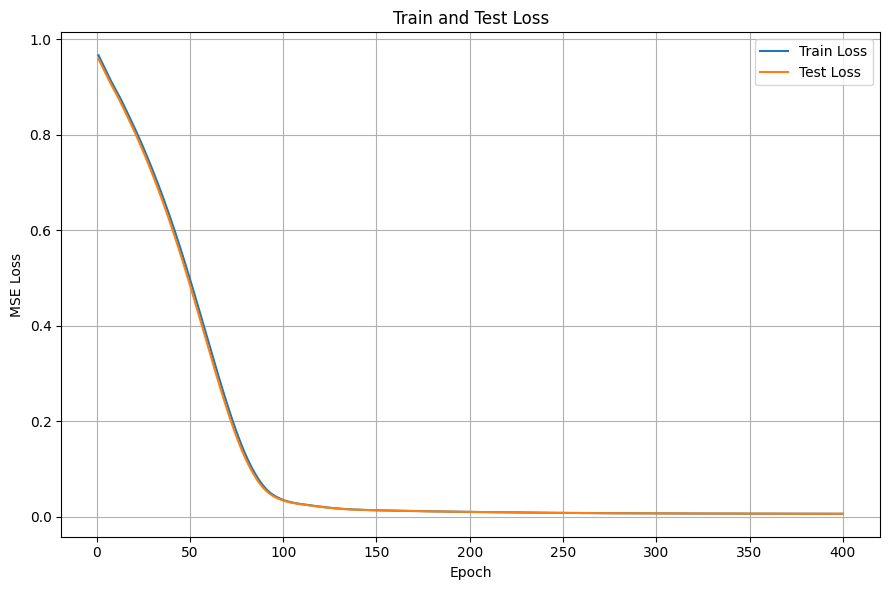

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/train_test_loss.jpg


In [64]:

# 9. Epoch별 Train/Test loss 저장

epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(9, 6))

plt.plot(epochs, train_loss_history, label='Train Loss')
plt.plot(epochs, test_loss_history, label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train and Test Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()

loss_path = os.path.join(
    RESULT_DIR,
    'train_test_loss.jpg'
)

plt.savefig(loss_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', loss_path)


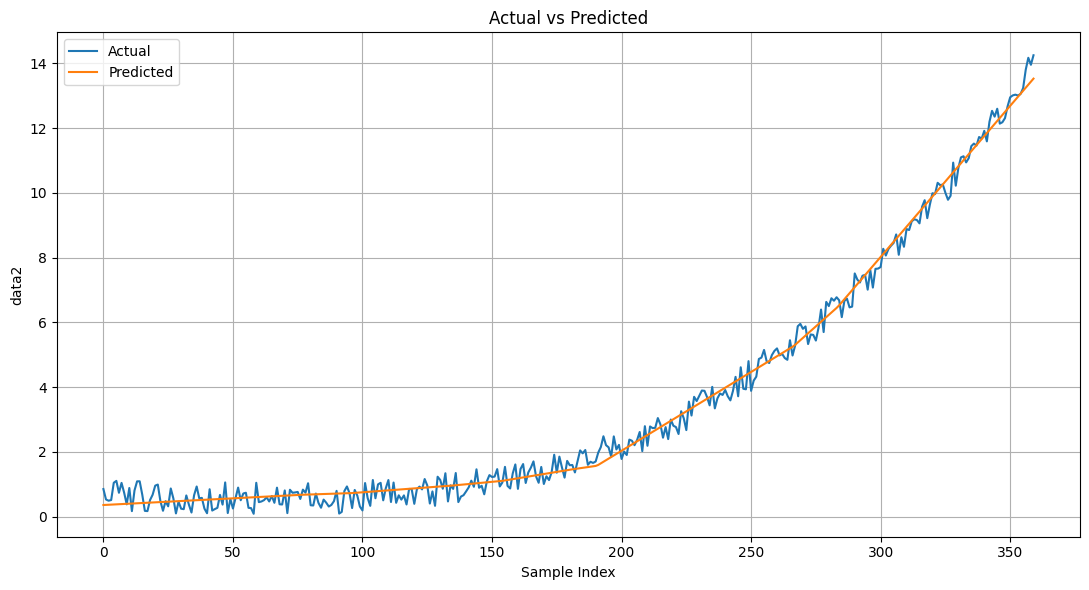

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/actual_vs_predicted.jpg


In [65]:

# 10. 실제값/추정값 비교 저장

sample_index = np.arange(len(y_test))

plt.figure(figsize=(11, 6))

plt.plot(
    sample_index,
    y_test.flatten(),
    label='Actual',
    linewidth=1.5
)

plt.plot(
    sample_index,
    y_test_pred.flatten(),
    label='Predicted',
    linewidth=1.5
)

plt.xlabel('Sample Index')
plt.ylabel('data2')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.legend()
plt.tight_layout()

comparison_path = os.path.join(
    RESULT_DIR,
    'actual_vs_predicted.jpg'
)

plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', comparison_path)


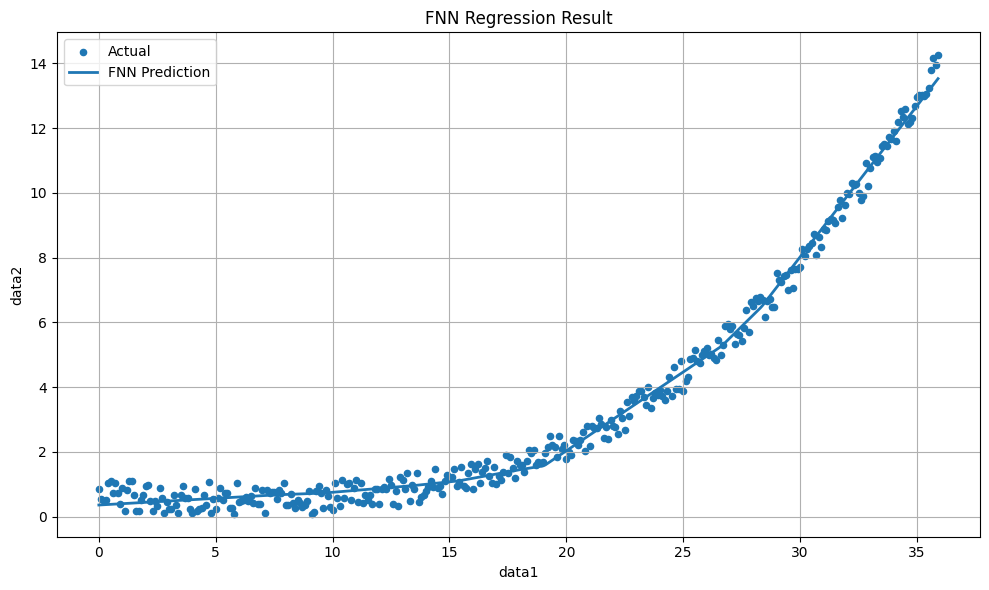

Saved: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/fnn_regression_result.jpg


In [66]:

# 11. data1 기준 회귀 결과 저장

sort_idx = np.argsort(X_test.flatten())

x_sorted = X_test.flatten()[sort_idx]
y_actual_sorted = y_test.flatten()[sort_idx]
y_pred_sorted = y_test_pred.flatten()[sort_idx]

plt.figure(figsize=(10, 6))

plt.scatter(
    x_sorted,
    y_actual_sorted,
    s=20,
    label='Actual'
)

plt.plot(
    x_sorted,
    y_pred_sorted,
    linewidth=2,
    label='FNN Prediction'
)

plt.xlabel('data1')
plt.ylabel('data2')
plt.title('FNN Regression Result')
plt.grid(True)
plt.legend()
plt.tight_layout()

regression_path = os.path.join(
    RESULT_DIR,
    'fnn_regression_result.jpg'
)

plt.savefig(regression_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', regression_path)


In [67]:
# ============================================================
# 결과 CSV, 학습 이력 CSV, PyTorch 모델(.pt) 저장
# ============================================================

model_path = os.path.join(
    RESULT_DIR,
    'fnn_model.pt'
)

model_cpu = model.to('cpu')
model_cpu.eval()

torch.save(
    model_cpu.state_dict(),
    model_path
)

if os.path.exists(model_path):
    print('모델 저장 성공')
    print('경로:', model_path)
    print('크기:', os.path.getsize(model_path), 'bytes')
else:
    print('모델 저장 실패')

print('x_mean:', x_scaler.mean_.astype(np.float32))
print('x_scale:', x_scaler.scale_.astype(np.float32))
print('y_mean:', y_scaler.mean_.astype(np.float32))
print('y_scale:', y_scaler.scale_.astype(np.float32))

모델 저장 성공
경로: /content/drive/MyDrive/Colab Notebooks/Basic_example/data/pytorch_results/fnn_model.pt
크기: 4201 bytes
x_mean: [17.95]
x_scale: [10.392264]
y_mean: [3.5473754]
y_scale: [3.7951794]
